In [1]:
import pandas as pd  # Data handling
from sklearn.model_selection import train_test_split  # Train/Test split
from sklearn.preprocessing import StandardScaler  # Feature scaling
from sklearn.linear_model import LinearRegression  # Regression model
from sklearn.ensemble import RandomForestRegressor  # Ensemble model
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Dataset3.csv")
print(df.head())

   Size  Bedrooms  Bathrooms  Age  Garage  Basement   Price
0  2100         3          2   20       1         1  400000
1  1600         2          1   15       0         0  330000
2  2400         4          3    5       1         1  500000
3  1416         2          2   20       0         0  250000
4  3000         4          3    8       1         1  600000


In [3]:
df.isnull().sum()

Size         0
Bedrooms     0
Bathrooms    0
Age          0
Garage       0
Basement     0
Price        0
dtype: int64

In [4]:
X = df.drop("Price",axis=1)
y = df['Price']

In [13]:
sc = StandardScaler()
Xsc = sc.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(Xsc, y, test_size=0.2, random_state=42)

In [15]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [16]:
y_pred_lr = lr_model.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression MSE:", mse_lr)
print("Linear Regression R2 Score:", r2_lr)

Linear Regression MSE: 136364289.15600112
Linear Regression R2 Score: 0.9908042154456806


In [17]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [18]:
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MSE:", mse_rf)
print("Random Forest R2 Score:", r2_rf)

Random Forest MSE: 271493414.9305555
Random Forest R2 Score: 0.98169172466582


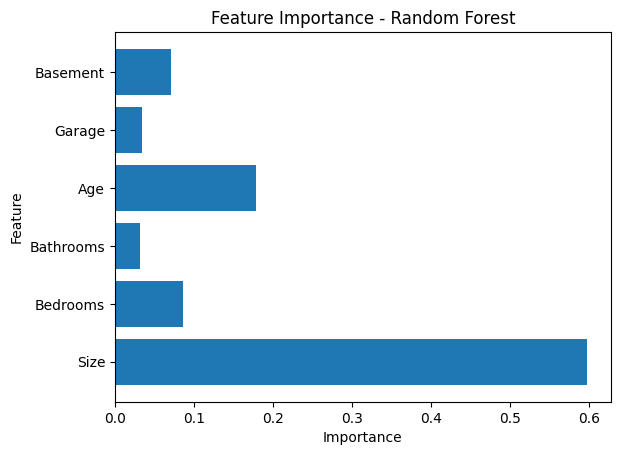

In [19]:
import matplotlib.pyplot as plt

feature_importances = rf_model.feature_importances_
features = X.columns

plt.barh(features, feature_importances)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.show()